# Gene Type Comparison Notebook Template

This notebook contains the full code to analyze the performance of an `.h5ad` dataset in terms of its full gene set and lncRNA gene subset.

**Note:** The input data file should be a single-cell RNA-seq dataset in h5ad format, with cell type annotations in the obs dataframe and gene annotations in the var dataframe.

**Note:** If using GitHub for version control and repository sharing, ensure that you add the path to your data folder to the repository's `.gitignore` file, to prevent yourself from exceeding the GitHub's storage limits.

In [5]:
# libraries
import sys
import os
from pathlib import Path
import numpy as np
import random
import pandas as pd
import scanpy as sc
import anndata as ad
import matplotlib.pyplot as plt
import plotly.io as pio
pio.renderers.default = "notebook"
import nsforest as ns
from nsforest import utils
import celltypist as ct

In [17]:
# configs
code_folder = "/Users/vbecker/NSForest-ncRNA" # path to the NSForest-ncRNA folder
sys.path.insert(0, os.path.abspath(code_folder))

data_folder = "../beckersv_data/" # path to folder containing the input data file (.h5ad format)
file = data_folder + "data_spc.h5ad"

output_folder = "../beckersv_output/spc/"

to_downsample = False # True if you want to downsample the dataset to a specific number of cells, 
                     # False otherwise

to_downsample_n = 10000 # Number of cells to downsample each cluster to, if to_downsample is True

seed = 0 # random seed for reproducibility
np.random.seed(seed) # set np seed
random.seed(seed) # set random seed

## Data Exploration

### Loading AnnData file

In [7]:
adata_raw = sc.read_h5ad(file)
adata_raw

AnnData object with n_obs × n_vars = 24190 × 58232
    obs: 'roi', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'assay_ontology_term_id', 'sex_ontology_term_id', 'development_stage_ontology_term_id', 'donor_id', 'suspension_type', 'dissection', 'fraction_mitochondrial', 'fraction_unspliced', 'cell_cycle_score', 'total_genes', 'total_UMIs', 'sample_id', 'supercluster_term', 'cluster_id', 'subcluster_id', 'is_primary_data', 'tissue_type', 'tissue_ontology_term_id', 'cell_type_ontology_term_id', 'Region', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'Biotype', 'Chromosome', 'End', 'Gene', 'Start', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type'
    uns: 'batch_condition', 'citation', 'organism', 'organism_ontology_term_id', 'schema_reference', 'schema_version', 'title'
    obsm: 'X_UMAP', 'X_tSNE'

### Looking at sample labels

In [8]:
adata_raw.obs_names # sample names
adata_raw.obs.columns # sample metadata

Index(['roi', 'disease_ontology_term_id',
       'self_reported_ethnicity_ontology_term_id', 'assay_ontology_term_id',
       'sex_ontology_term_id', 'development_stage_ontology_term_id',
       'donor_id', 'suspension_type', 'dissection', 'fraction_mitochondrial',
       'fraction_unspliced', 'cell_cycle_score', 'total_genes', 'total_UMIs',
       'sample_id', 'supercluster_term', 'cluster_id', 'subcluster_id',
       'is_primary_data', 'tissue_type', 'tissue_ontology_term_id',
       'cell_type_ontology_term_id', 'Region', 'cell_type', 'assay', 'disease',
       'sex', 'tissue', 'self_reported_ethnicity', 'development_stage',
       'observation_joinid'],
      dtype='object')

### Looking at genes

**Note:** `adata.var_names` must be unique. If there is a problem, usually it can be solved by assigning `adata.var.index = adata.var["ensembl_id"]`. 

In [9]:
print(adata_raw.var_names) # gene names
print(adata_raw.var.columns) # gene metadata

Index(['ENSG00000287383', 'ENSG00000100097', 'ENSG00000271850',
       'ENSG00000156049', 'ENSG00000231373', 'ENSG00000232560',
       'ENSG00000233359', 'ENSG00000172197', 'ENSG00000286271',
       'ENSG00000150656',
       ...
       'ENSG00000235582', 'ENSG00000286030', 'ENSG00000285420',
       'ENSG00000277496', 'ENSG00000281103', 'ENSG00000260212',
       'ENSG00000279753', 'ENSG00000279617', 'ENSG00000254835',
       'ENSG00000100351'],
      dtype='object', length=58232)
Index(['Biotype', 'Chromosome', 'End', 'Gene', 'Start', 'feature_is_filtered',
       'feature_name', 'feature_reference', 'feature_biotype',
       'feature_length', 'feature_type'],
      dtype='object')


In [10]:
print(adata_raw.var["feature_type"].value_counts()) # gene counts by feature type

feature_type
protein_coding                        19358
lncRNA                                15460
processed_pseudogene                   9355
misc_RNA                               2214
snRNA                                  1910
unprocessed_pseudogene                 1894
miRNA                                  1877
transcribed_unprocessed_pseudogene     1552
transcribed_processed_pseudogene       1123
TEC                                     994
snoRNA                                  939
rRNA_pseudogene                         496
IG_V_pseudogene                         185
transcribed_unitary_pseudogene          179
IG_V_gene                               143
TR_V_gene                               106
TR_J_gene                                79
unitary_pseudogene                       79
rRNA                                     53
scaRNA                                   49
IG_D_gene                                37
TR_V_pseudogene                          33
Mt_tRNA            

## Downsampling and Subsetting

### Defining cluster and gene type subset.

**Note:** Some datasets have multiple annotations per sample (ex. "broad_cell_type" and "granular_cell_type"). NS-Forest can be run on multiple `cluster_header`'s. Combining the parent and child markers may improve classification results. 

In [11]:
cluster_header = "cell_type" # column name in adata.obs that contains the cluster labels
subset_col = "feature_type"  # column name in adata.var that contains the gene feature type
subset_gene = "lncRNA"       # feature type to subset the data by (EX: "lncRNA" or "protein_coding")

### Checking cell annotation sizes.

**Note:** Some datasets are too large and need to be downsampled to be run through the pipeline. When downsampling, be sure to have all the granular cluster annotations represented. 

In [12]:
pd.DataFrame(adata_raw.obs[cluster_header].value_counts()).reset_index()

,cell_type,count
0,oligodendrocyte,11503
1,neuron,4910
2,astrocyte,2435
3,oligodendrocyte precursor cell,1970
4,microglial cell,1647
5,cerebellar granule cell,859
6,endothelial cell,215
7,T cell,202
8,ependymal cell,147
9,pericyte,78


### (Optional) Downsampling.

**Note:** Clusters with less cells than specified in `to_downsample_n` will have all cells sampled.

In [ ]:
if to_downsample:
    adata = ct.samples.downsample_adata(adata_raw, mode = "each", n_cells = to_downsample_n, by = cluster_header,
                                        random_state = seed, return_index = False)
    pd.DataFrame(adata.obs[cluster_header].value_counts()).reset_index()
else:
    adata = adata_raw

### Creating gene type subset data.

In [ ]:
# keep only lncRNA genes
# adata_subset = adata[:, adata.var[subset_col] == subset_gene].copy()

# compute lncrna mask on the adata_raw object
lncrna_mask = adata_raw.var[subset_col].isin([subset_gene])
adata_subset = adata[:, lncrna_mask]

print(adata.shape)
print(adata_subset.shape)

# save
# filename = file.replace(".h5ad", f"_subset_{subset_gene}.h5ad")
# print(f"Saving subset anndata object as...\n{filename}")
# adata_subset.write_h5ad(filename)

(24190, 58232)
(24190, 15460)


## Preprocessing

### Generating scanpy dendrograms

**Note:** Only run if there is no pre-defined dendrogram order. This step can still be run with no effects, but the runtime may increase. 

Dendrogram order is stored in `adata.uns["dendrogram_cluster"]["categories_ordered"]`. 

Saving dendrogram as...
../beckersv_output/spc/dendrogram_cell_type.png


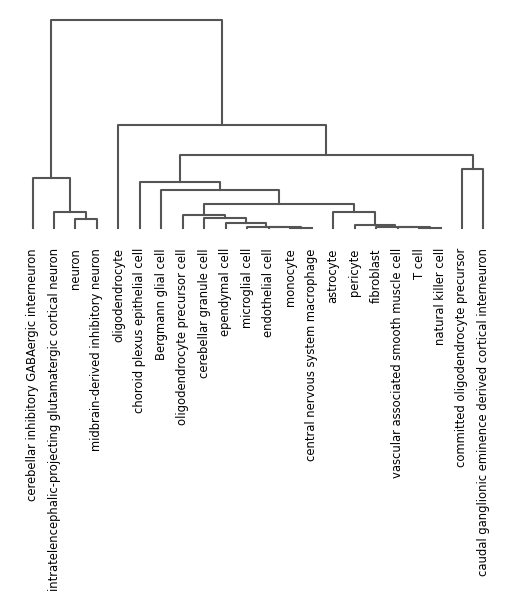

PosixPath('../beckersv_output/spc/dendrogram_cell_type_full.png')

In [21]:
# full adata
if not adata.obsm or "X_pca" not in adata.obsm:
    sc.pp.pca(adata, random_state=seed)

ns.pp.dendrogram(adata, cluster_header, save = True, output_folder = output_folder, outputfilename_suffix = cluster_header)
Path(f"dendrogram_{cluster_header}.png").rename(
    output_folder + f"dendrogram_{cluster_header}_full.png"
)

Saving dendrogram as...
../beckersv_output/spc/dendrogram_cell_type.png


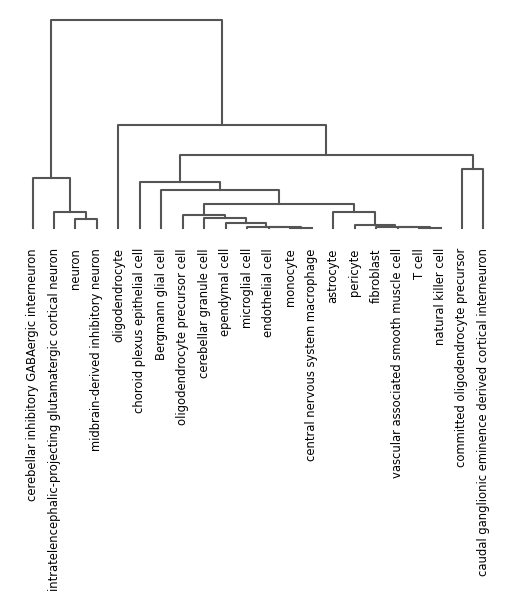

PosixPath('../beckersv_output/spc/dendrogram_cell_type_subset.png')

In [22]:
# subset adata
if not adata_subset.obsm or "X_pca" not in adata_subset.obsm:
    sc.pp.pca(adata_subset, random_state=seed)

ns.pp.dendrogram(adata_subset, cluster_header, save = True, output_folder = output_folder, outputfilename_suffix = cluster_header)
Path(f"dendrogram_{cluster_header}.png").rename(
    output_folder + f"dendrogram_{cluster_header}_subset.png"
)

### Calculating cluster medians per gene

Run `ns.pp.prep_medians` before running NS-Forest.

**Note:** Do **not** run if evaluating marker lists. Do **not** run when generating scanpy plots (e.g. dot plot, violin plot, matrix plot). 

In [23]:
# full adata
adata = ns.pp.prep_medians(adata, cluster_header)
adata.varm[f"medians_{cluster_header}"].head()

Calculating medians per cluster: 100%|██████████| 22/22 [00:09<00:00,  2.22it/s]


Saving medians as adata.varm.medians_cell_type
median: 0.0
mean: 0.084
std: 2.345
Only positive genes selected. 11249 positive genes out of 58232 total genes
--- 10.274533033370972 seconds ---


,Bergmann glial cell,T cell,astrocyte,caudal ganglionic eminence derived cortical interneuron,central nervous system macrophage,cerebellar granule cell,cerebellar inhibitory GABAergic interneuron,choroid plexus epithelial cell,committed oligodendrocyte precursor,endothelial cell,...,intratelencephalic-projecting glutamatergic cortical neuron,microglial cell,midbrain-derived inhibitory neuron,monocyte,natural killer cell,neuron,oligodendrocyte,oligodendrocyte precursor cell,pericyte,vascular associated smooth muscle cell
ENSG00000100097,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,1.0
ENSG00000156049,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,3.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
ENSG00000150656,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
ENSG00000273507,0.0,0.0,0.0,0.5,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ENSG00000116147,2.0,0.0,1.0,1.0,0.0,0.0,2.0,0.0,22.0,0.0,...,26.0,0.0,2.0,0.0,0.0,1.0,0.0,12.0,0.0,0.0


In [24]:
# subset adata
adata_subset = ns.pp.prep_medians(adata_subset, cluster_header)
adata_subset.varm[f"medians_{cluster_header}"].head()

Calculating medians per cluster: 100%|██████████| 22/22 [00:02<00:00,  8.57it/s]

Saving medians as adata.varm.medians_cell_type
median: 0.0
mean: 0.04
std: 3.71
Only positive genes selected. 1426 positive genes out of 15460 total genes
--- 2.6114630699157715 seconds ---


,Bergmann glial cell,T cell,astrocyte,caudal ganglionic eminence derived cortical interneuron,central nervous system macrophage,cerebellar granule cell,cerebellar inhibitory GABAergic interneuron,choroid plexus epithelial cell,committed oligodendrocyte precursor,endothelial cell,...,intratelencephalic-projecting glutamatergic cortical neuron,microglial cell,midbrain-derived inhibitory neuron,monocyte,natural killer cell,neuron,oligodendrocyte,oligodendrocyte precursor cell,pericyte,vascular associated smooth muscle cell
ENSG00000273507,0.0,0.0,0.0,0.5,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ENSG00000262223,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ENSG00000235189,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ENSG00000236494,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ENSG00000286364,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Calculating binary scores per gene per cluster

Run `ns.pp.prep_binary_scores` before running NS-Forest. Do not need to run if evaluating marker lists. Do not need to run when generating scanpy plots. 

In [25]:
# full adata
adata = ns.pp.prep_binary_scores(adata, cluster_header)
adata.varm[f"binary_scores_{cluster_header}"].head()

Calculating binary scores per cluster: 100%|██████████| 22/22 [00:10<00:00,  2.14it/s]

Saving binary scores as adata.varm.binary_scores_cell_type
median: 0.0
mean: 0.116
std: 0.293
--- 10.317651987075806 seconds ---


,Bergmann glial cell,T cell,astrocyte,caudal ganglionic eminence derived cortical interneuron,central nervous system macrophage,cerebellar granule cell,cerebellar inhibitory GABAergic interneuron,choroid plexus epithelial cell,committed oligodendrocyte precursor,endothelial cell,...,intratelencephalic-projecting glutamatergic cortical neuron,microglial cell,midbrain-derived inhibitory neuron,monocyte,natural killer cell,neuron,oligodendrocyte,oligodendrocyte precursor cell,pericyte,vascular associated smooth muscle cell
ENSG00000100097,0.000000,0.0,0.000000,0.904762,0.0,0.0,0.000000,0.0,0.000000,0.0,...,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.952381,0.904762
ENSG00000156049,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,...,0.000000,0.0,0.984127,0.0,0.0,0.000000,0.952381,0.000000,0.000000,0.000000
ENSG00000150656,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,...,0.000000,0.0,0.000000,0.0,0.0,0.000000,1.000000,0.000000,0.000000,0.000000
ENSG00000273507,0.000000,0.0,0.000000,1.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,...,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
ENSG00000116147,0.690476,0.0,0.619048,0.619048,0.0,0.0,0.690476,0.0,0.906926,0.0,...,0.921245,0.0,0.690476,0.0,0.0,0.619048,0.000000,0.869048,0.000000,0.000000


In [27]:
# subset adata
adata_subset = ns.pp.prep_binary_scores(adata_subset, cluster_header)
adata_subset.varm[f"binary_scores_{cluster_header}"].head()

Calculating binary scores per cluster: 100%|██████████| 22/22 [00:01<00:00, 16.13it/s]

Saving binary scores as adata.varm.binary_scores_cell_type
median: 0.0
mean: 0.074
std: 0.252
--- 1.3728280067443848 seconds ---


,Bergmann glial cell,T cell,astrocyte,caudal ganglionic eminence derived cortical interneuron,central nervous system macrophage,cerebellar granule cell,cerebellar inhibitory GABAergic interneuron,choroid plexus epithelial cell,committed oligodendrocyte precursor,endothelial cell,...,intratelencephalic-projecting glutamatergic cortical neuron,microglial cell,midbrain-derived inhibitory neuron,monocyte,natural killer cell,neuron,oligodendrocyte,oligodendrocyte precursor cell,pericyte,vascular associated smooth muscle cell
ENSG00000273507,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ENSG00000262223,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ENSG00000235189,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ENSG00000236494,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ENSG00000286364,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Saving preprocessed AnnData as new `.h5ad`.

In [28]:
# full adata
filename = file.replace(".h5ad", "_preprocessed.h5ad")
print(f"Saving new anndata object as...\n{filename}")
adata.write_h5ad(filename)
adata

Saving new anndata object as...
../beckersv_data/data_spc_preprocessed.h5ad


AnnData object with n_obs × n_vars = 24190 × 11249
    obs: 'roi', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'assay_ontology_term_id', 'sex_ontology_term_id', 'development_stage_ontology_term_id', 'donor_id', 'suspension_type', 'dissection', 'fraction_mitochondrial', 'fraction_unspliced', 'cell_cycle_score', 'total_genes', 'total_UMIs', 'sample_id', 'supercluster_term', 'cluster_id', 'subcluster_id', 'is_primary_data', 'tissue_type', 'tissue_ontology_term_id', 'cell_type_ontology_term_id', 'Region', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'Biotype', 'Chromosome', 'End', 'Gene', 'Start', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type'
    uns: 'batch_condition', 'citation', 'organism', 'organism_ontology_term_id', 'schema_reference', 'schema_version', 'title', 'pca', 'dendrogram_cell_type'
    obsm: 'X_UMAP'

In [29]:
# subset adata
filename = file.replace(".h5ad", f"_subset_{subset_gene}_preprocessed.h5ad")
print(f"Saving new anndata object as...\n{filename}")
adata_subset.write_h5ad(filename)
adata_subset

Saving new anndata object as...
../beckersv_data/data_spc_subset_lncRNA_preprocessed.h5ad


AnnData object with n_obs × n_vars = 24190 × 1426
    obs: 'roi', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'assay_ontology_term_id', 'sex_ontology_term_id', 'development_stage_ontology_term_id', 'donor_id', 'suspension_type', 'dissection', 'fraction_mitochondrial', 'fraction_unspliced', 'cell_cycle_score', 'total_genes', 'total_UMIs', 'sample_id', 'supercluster_term', 'cluster_id', 'subcluster_id', 'is_primary_data', 'tissue_type', 'tissue_ontology_term_id', 'cell_type_ontology_term_id', 'Region', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'Biotype', 'Chromosome', 'End', 'Gene', 'Start', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type'
    uns: 'batch_condition', 'citation', 'organism', 'organism_ontology_term_id', 'schema_reference', 'schema_version', 'title', 'dendrogram_cell_type'
    obsm: 'X_UMAP', 'X_tSN

### Visualization of preprocessing steps.

Saving adata.varm[medians_cell_type] as histogram as...
../beckersv_output/spc/histogram_medians_cell_type.png


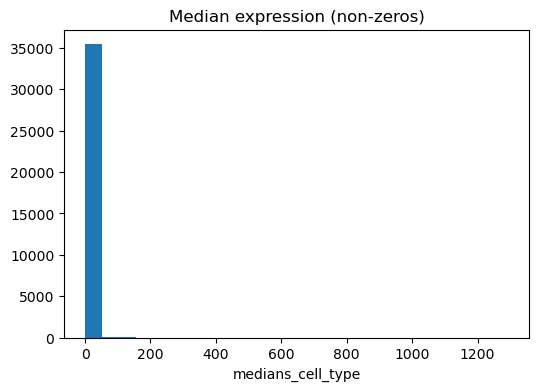

Saving adata.varm[medians_cell_type] as histogram as...
../beckersv_output/spc/histogram_medians_cell_type.png


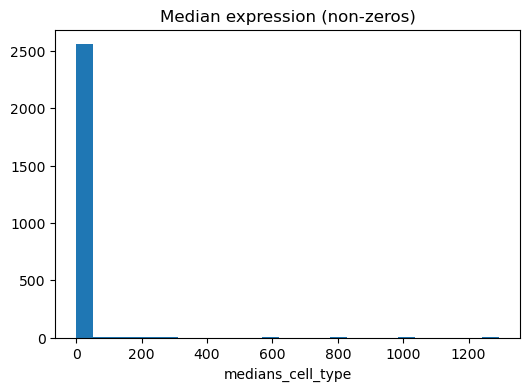

In [30]:
# cluster medians (unscaled)
ns.pp.plot_varm(adata, f"medians_{cluster_header}", nonzero = True, save = True, output_folder = output_folder)
ns.pp.plot_varm(adata_subset, f"medians_{cluster_header}", nonzero = True, save = True, output_folder = output_folder)

In [ ]:
# cluster medians (log scale)
ns.pp.plot_varm(adata, f"medians_{cluster_header}", scale = "log", save = True, output_folder = output_folder)
ns.pp.plot_varm(adata_subset, f"medians_{cluster_header}", scale = "log", save = True, output_folder = output_folder)

In [ ]:
# binary scores (unscaled)
ns.pp.plot_varm(adata, f"binary_scores_{cluster_header}", nonzero = True, save = True, output_folder = output_folder)
ns.pp.plot_varm(adata_subset, f"binary_scores_{cluster_header}", nonzero = True, save = True, output_folder = output_folder)

In [ ]:
# binary scores (log scale)
ns.pp.plot_varm(adata, f"binary_scores_{cluster_header}", scale = "log", save = True, output_folder = output_folder)
ns.pp.plot_varm(adata_subset, f"binary_scores_{cluster_header}", scale = "log", save = True, output_folder = output_folder)

## Running NS-Forest

**Note:** Do not run NS-Forest if only evaluating input marker lists. 

In [ ]:
# full adata
outputfilename_prefix = cluster_header
results = ns.nsforesting.NSForest(adata, cluster_header, save_supplementary = True, save = True, output_folder = output_folder, outputfilename_prefix = outputfilename_prefix)
results

In [ ]:
# subset adata
outputfilename_prefix_subset = cluster_header + "_subset_" + subset_gene
results_subset = ns.nsforesting.NSForest(adata_subset, cluster_header, save_supplementary = True, save = True, output_folder = output_folder, outputfilename_prefix = outputfilename_prefix_subset)
results_subset

## Visualization of Results

**Note:** Assign pre-defined dendrogram order here **or** use `adata.uns["dendrogram_" + cluster_header]["categories_ordered"]`. 

In [ ]:
to_plot = results.copy()
to_plot_subset = results_subset.copy()

In [ ]:
# dendrogram full adata
dendrogram = [] # custom dendrogram order
dendrogram = list(adata.uns["dendrogram_" + cluster_header]["categories_ordered"])
to_plot["clusterName"] = to_plot["clusterName"].astype("category")
to_plot["clusterName"] = to_plot["clusterName"].cat.set_categories(dendrogram)
to_plot = to_plot.sort_values("clusterName")
to_plot = to_plot.rename(columns = {"NSForest_markers": "markers"})

In [ ]:
# dendrogram subset adata
dendrogram_subset = [] # custom dendrogram order
dendrogram_subset = list(adata.uns["dendrogram_" + cluster_header]["categories_ordered"])
to_plot_subset["clusterName"] = to_plot_subset["clusterName"].astype("category")
to_plot_subset["clusterName"] = to_plot_subset["clusterName"].cat.set_categories(dendrogram_subset)
to_plot_subset = to_plot_subset.sort_values("clusterName")
to_plot_subset = to_plot_subset.rename(columns = {"NSForest_markers": "markers"})

In [ ]:
# marker dictionary full adata
markers_dict = dict(zip(to_plot["clusterName"], to_plot["markers"]))
markers_dict

# marker dictionary subset adata
markers_dict_subset = dict(zip(to_plot_subset["clusterName"], to_plot_subset["markers"]))
markers_dict_subset

In [ ]:
# dotplot
ns.pl.dotplot(adata, markers_dict, cluster_header, dendrogram = dendrogram, save = True, output_folder = output_folder, outputfilename_suffix = outputfilename_prefix)
ns.pl.dotplot(adata_subset, markers_dict_subset, cluster_header, dendrogram = dendrogram_subset, save = True, output_folder = output_folder, outputfilename_suffix = outputfilename_prefix_subset)

In [ ]:
# stacked violin plot
ns.pl.stackedviolin(adata, markers_dict, cluster_header, dendrogram = dendrogram, save = True, output_folder = output_folder, outputfilename_suffix = outputfilename_prefix)
ns.pl.stackedviolin(adata_subset, markers_dict_subset, cluster_header, dendrogram = dendrogram_subset, save = True, output_folder = output_folder, outputfilename_suffix = outputfilename_prefix_subset)

In [ ]:
# heatmap
ns.pl.matrixplot(adata, markers_dict, cluster_header, dendrogram = dendrogram, save = True, output_folder = output_folder, outputfilename_suffix = outputfilename_prefix)
ns.pl.matrixplot(adata_subset, markers_dict_subset, cluster_header, dendrogram = dendrogram_subset, save = True, output_folder = output_folder, outputfilename_suffix = outputfilename_prefix_subset)

### Plotting classification metrics from NS-Forest results

In [ ]:
ns.pl.boxplot(results, ["f_score", "precision", "recall", "onTarget"], save = True, output_folder = output_folder, outputfilename_prefix = outputfilename_prefix)
ns.pl.boxplot(results_subset, ["f_score", "precision", "recall", "onTarget"], save = True, output_folder = output_folder, outputfilename_prefix = outputfilename_prefix_subset)

### Plotting metrics vs clusterSize

In [ ]:
# f_score
ns.pl.scatter_w_clusterSize(results, "f_score", save = True, output_folder = output_folder, outputfilename_prefix = outputfilename_prefix)
ns.pl.scatter_w_clusterSize(results_subset, "f_score", save = True, output_folder = output_folder, outputfilename_prefix = outputfilename_prefix_subset)

In [ ]:
# precision
ns.pl.scatter_w_clusterSize(results, "precision", save = True, output_folder = output_folder, outputfilename_prefix = outputfilename_prefix)
ns.pl.scatter_w_clusterSize(results_subset, "precision", save = True, output_folder = output_folder, outputfilename_prefix = outputfilename_prefix_subset)

In [ ]:
# recall
ns.pl.scatter_w_clusterSize(results, "recall", save = True, output_folder = output_folder, outputfilename_prefix = outputfilename_prefix)
ns.pl.scatter_w_clusterSize(results_subset, "recall", save = True, output_folder = output_folder, outputfilename_prefix = outputfilename_prefix_subset)

In [ ]:
# onTarget
ns.pl.scatter_w_clusterSize(results, "onTarget", save = True, output_folder = output_folder, outputfilename_prefix = outputfilename_prefix)
ns.pl.scatter_w_clusterSize(results_subset, "onTarget", save = True, output_folder = output_folder, outputfilename_prefix = outputfilename_prefix_subset)